# 08, Understanding the pipeline end to end

Run this *after* `make clean features sample spillovers panel decomposition horse-race` (and optionally `make crisis`). It loads the gold outputs and **shows** what each stage produced, in plain language, so you can explain every box to the jury.

Sections:
1. **The sample**, who's in, who's out, and why
2. **The dependent variable**, what a spillover series actually looks like
3. **The headline**, a *smaller crypto share* of FX variance under stress (the reverse of H2)
4. **Is it just global risk-off?**, no (crypto survives openness×VIX / ×DXY)
5. **Is it openness, or development?**, the confound that reframes the result
6. **The mechanism**, share, not amount (and why it stays unresolved)
7. **Crisis flags**, the hyperinflation cases we keep + flag

See `PIPELINE.md` for the data flow and the thesis for the written results.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
GOLD = Path("../data/parquet/gold")  # run from notebooks/; adjust if needed
if not GOLD.exists():
    GOLD = Path("data/parquet/gold")

load = lambda n: pd.read_parquet(GOLD / f"{n}.parquet")
membership = load("sample_membership")
spill      = load("spillovers")
panel_coefs = load("step2_panel_coefs")
horse      = load("horse_race_coefs")
decomp     = load("decomp_coefs")
analysis   = load("step2_analysis")
crisis     = load("crisis_flags") if (GOLD / "crisis_flags.parquet").exists() else None

print({n: load(n).shape for n in ["sample_membership", "spillovers", "step2_panel_coefs", "horse_race_coefs", "decomp_coefs", "step2_analysis"]})

{'sample_membership': (178, 10), 'spillovers': (148181, 7), 'step2_panel_coefs': (109, 11), 'horse_race_coefs': (120, 12), 'decomp_coefs': (436, 12), 'step2_analysis': (148181, 15)}


## 1. The sample, who's in and why

The rule is **data quality only**: a country qualifies for a channel if it has enough coverage (≥0.80 of business days) and isn't too *stale* (frozen-price share below the cap: 0.20 for equity, 0.40 for FX). Dashed lines are the thresholds; dropped countries are labelled. This is the picture that kills the "you cherry-picked the countries" objection.

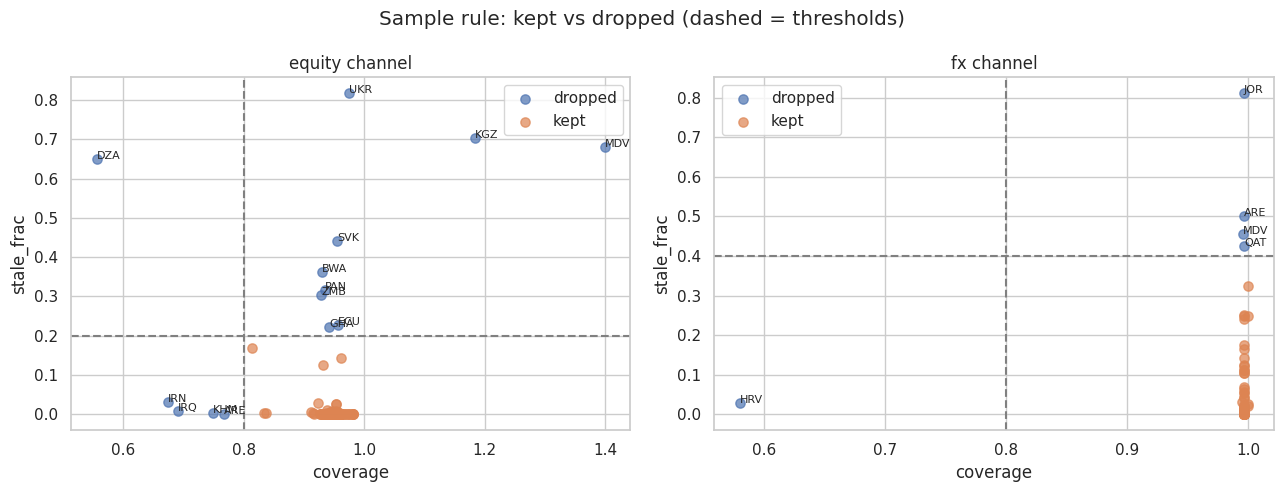

,qualify,total
channel,,
equity,78,92
fx,81,86


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, ch in zip(axes, ["equity", "fx"]):
    d = membership[membership.channel == ch]
    for passed, sub in d.groupby("passes"):
        ax.scatter(sub.coverage, sub.stale_frac, s=45, alpha=.7,
                   label="kept" if passed else "dropped")
    cap = 0.20 if ch == "equity" else 0.40
    ax.axvline(0.80, ls="--", c="grey"); ax.axhline(cap, ls="--", c="grey")
    for _, r in d[~d.passes].iterrows():
        ax.annotate(r.country_id, (r.coverage, r.stale_frac), fontsize=8)
    ax.set(title=f"{ch} channel", xlabel="coverage", ylabel="stale_frac")
    ax.legend()
fig.suptitle("Sample rule: kept vs dropped (dashed = thresholds)")
plt.tight_layout(); plt.show()

membership.groupby("channel").passes.agg(qualify="sum", total="count")

## 2. The dependent variable, what a spillover series is

Step 1 gives, for each country and day, the **share of the local market's variance attributable to Bitcoin** (a rolling generalized-FEVD number between 0 and 1). Below: the most open vs the most closed country in the sample, for both channels. This is literally what Step 2 regresses on.

most closed: UKR (KAOPEN=0.00)   most open: ZMB (KAOPEN=1.00)


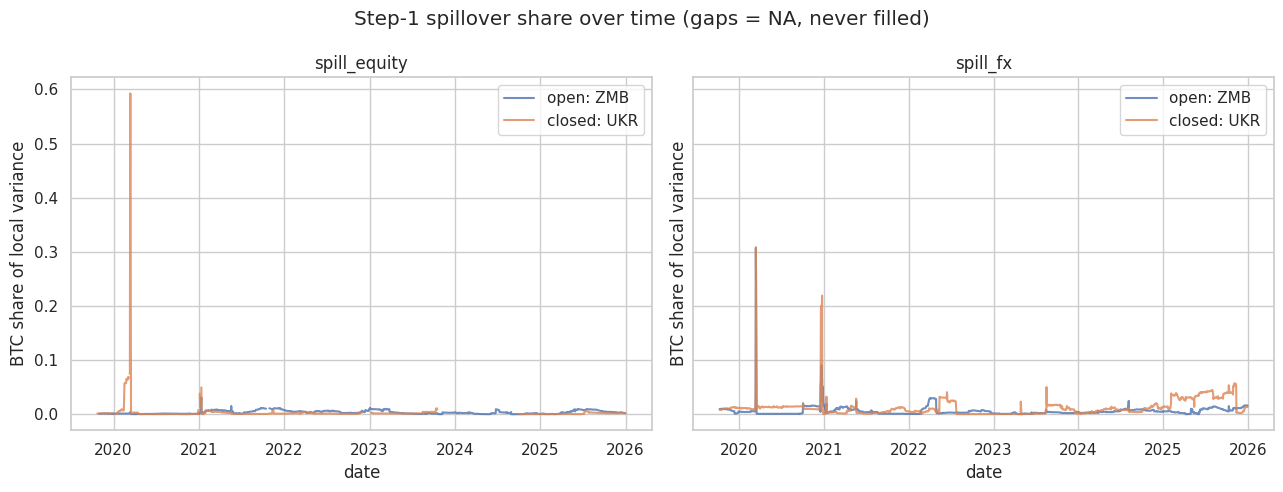

In [3]:
ci = analysis.groupby("country_id").chinn_ito.first().sort_values()
closed_c, open_c = ci.index[0], ci.index[-1]
print(f"most closed: {closed_c} (KAOPEN={ci.iloc[0]:.2f})   most open: {open_c} (KAOPEN={ci.iloc[-1]:.2f})")

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, col in zip(axes, ["spill_equity", "spill_fx"]):
    for c, lbl in [(open_c, f"open: {open_c}"), (closed_c, f"closed: {closed_c}")]:
        s = spill[spill.country_id == c].sort_values("date")
        ax.plot(s.date, s[col], alpha=.8, label=lbl)
    ax.set(title=col, xlabel="date", ylabel="BTC share of local variance")
    ax.legend()
fig.suptitle("Step-1 spillover share over time (gaps = NA, never filled)")
plt.tight_layout(); plt.show()

## 3. The headline, a *smaller crypto share* of FX variance under stress (reverse of H2)

The key term is `ci_x_cv` = **openness × crypto-volatility**. Negative means: the more crypto is stressed, the *smaller* crypto's **share** of FX variance in open countries relative to closed ones. Two cautions carry the whole interpretation:

- It's a **share, not an amount.** A smaller slice ≠ "crypto transmits less." Say "smaller crypto *share*", never "openness dampens crypto", §6 shows the *absolute* level doesn't move.
- It's an **interaction, not an average.** The raw cross-country correlation of openness with the *average* crypto FX share is actually *positive* (+0.16); the negative result is purely the *response to crypto stress*. On calm days openness makes ~no difference.

Red dots are p<0.05. FX clusters clearly negative; equity (plain panel) sits near zero.

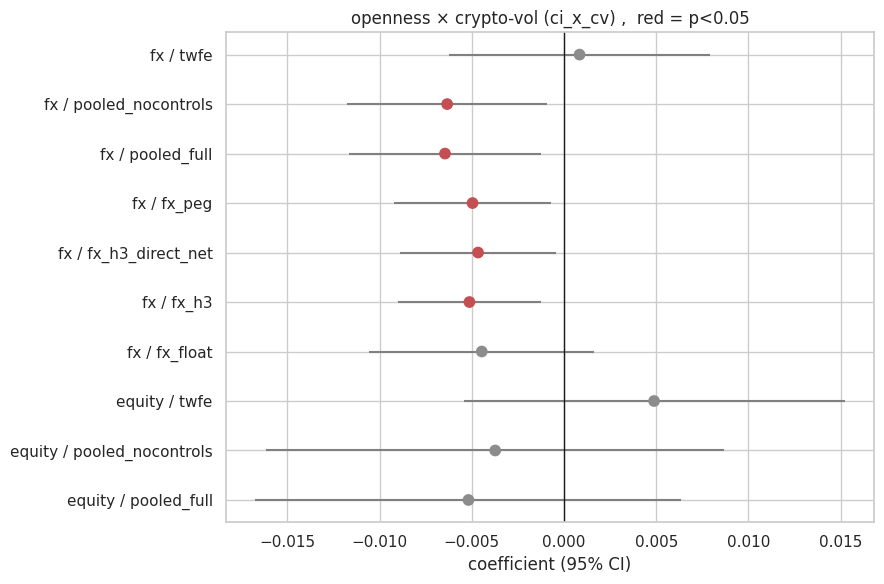

,channel,spec,coef,se,pval,nobs
0,equity,pooled_full,-0.005187,0.005894,0.378902,102491
1,equity,pooled_nocontrols,-0.003735,0.006331,0.555234,108758
2,equity,twfe,0.004879,0.005270,0.354544,117735
3,fx,fx_float,-0.004464,0.003117,0.152026,71286
4,fx,fx_h3,-0.005133,0.001986,0.009739,115873
5,fx,fx_h3_direct_net,-0.004665,0.002152,0.030226,115873
6,fx,fx_peg,-0.004965,0.002172,0.022272,44587
7,fx,pooled_full,-0.006456,0.002661,0.015265,115873
8,fx,pooled_nocontrols,-0.006340,0.002759,0.021590,121589
9,fx,twfe,0.000839,0.003603,0.815926,131312


In [4]:
k = panel_coefs[panel_coefs.term == "ci_x_cv"].copy().sort_values(["channel", "spec"])
k["label"] = k.channel + " / " + k.spec
colors = ["C3" if p < 0.05 else "C7" for p in k.pval]

fig, ax = plt.subplots(figsize=(9, 6))
ax.errorbar(k.coef, range(len(k)), xerr=1.96 * k.se, fmt="none", ecolor="grey")
ax.scatter(k.coef, range(len(k)), c=colors, zorder=3, s=55)
ax.set_yticks(range(len(k))); ax.set_yticklabels(k.label)
ax.axvline(0, c="k", lw=1)
ax.set(title="openness × crypto-vol (ci_x_cv) ,  red = p<0.05", xlabel="coefficient (95% CI)")
plt.tight_layout(); plt.show()

k[["channel", "spec", "coef", "se", "pval", "nobs"]].reset_index(drop=True)

## 4. The decisive test, crypto is not just global risk-off

We put `openness × VIX` and `openness × DXY` next to `openness × crypto`. If crypto were just "open markets swing in any panic", the crypto bar would collapse. Instead it survives, and in **equity** the VIX bar is *positive* while crypto is *negative*: **opposite directions ⇒ distinct channels.**

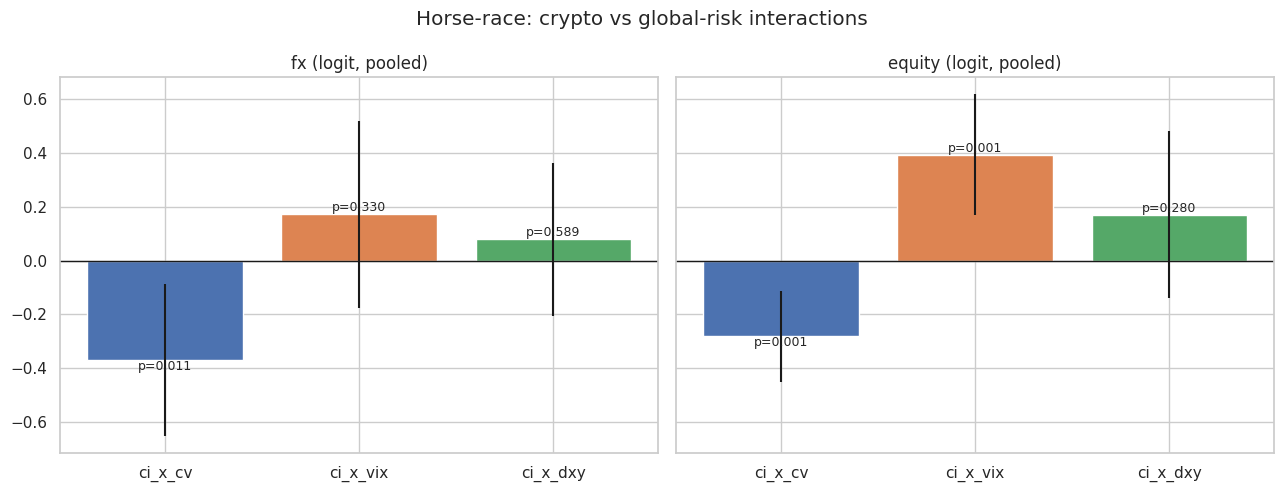

In [5]:
terms = ["ci_x_cv", "ci_x_vix", "ci_x_dxy"]
h = horse[(horse.model == "2_horserace") & (horse.dv == "logit") & (horse.spec == "pooled")]

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, ch in zip(axes, ["fx", "equity"]):
    d = h[h.channel == ch].set_index("term").reindex(terms)
    ax.bar(terms, d.coef, yerr=1.96 * d.se, color=["C0", "C1", "C2"])
    for i, (_, r) in enumerate(d.iterrows()):
        ax.text(i, r.coef, f"p={r.pval:.3f}", ha="center",
                va="bottom" if r.coef >= 0 else "top", fontsize=9)
    ax.axhline(0, c="k", lw=1); ax.set(title=f"{ch} (logit, pooled)")
fig.suptitle("Horse-race: crypto vs global-risk interactions")
plt.tight_layout(); plt.show()

## 5. Is it openness, or *development*?

Capital openness and GDP-per-capita move together (**r ≈ 0.68** across countries), and the headline only ever interacts crypto with *openness*. So we run a **second horse-race**, same crypto driver, *competing moderators* (openness, GDP, private-credit, all standardized). The verdict is sobering: in FX, `openness × crypto` is significant **alone** (p ≈ 0.006–0.03), but **loses all significance the instant `development × crypto` enters**, in *every* cell (e.g. FX level p: 0.015 → 0.95), and GDP carries the sign (it's even significant in *equity*, where openness never was).

⇒ The moderator is **financial-market maturity**, not capital controls *specifically*. Report the headline as "openness, *or the financial development it travels with*." Output: `gold/dev_horse_race_coefs.parquet` (`make horse-race`).

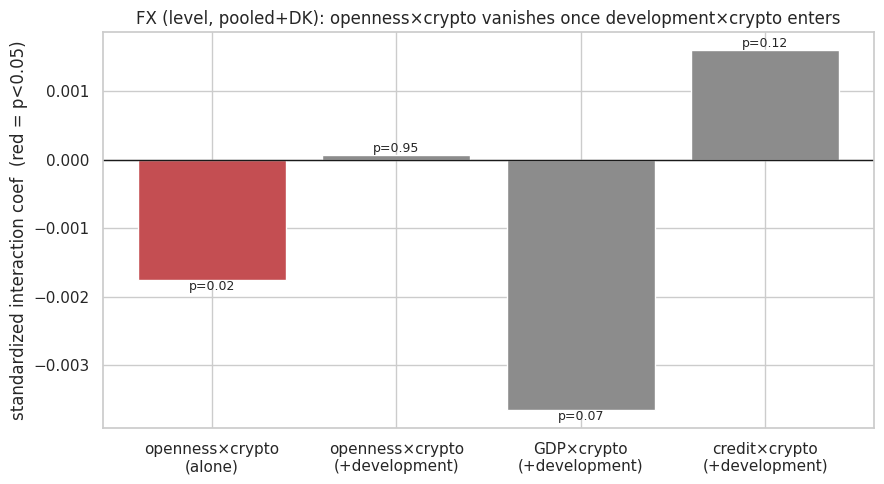

,dv,spec,model,coef,pval
0,level,pooled,1_openness_only,-0.001757,0.015265
1,level,pooled,2_dev_added,0.000063,0.949707
2,level,twfe,1_openness_only,-0.001543,0.032246
3,level,twfe,2_dev_added,0.000187,0.834665
4,logit,pooled,1_openness_only,-0.114434,0.006332
5,logit,pooled,2_dev_added,-0.051794,0.222494
6,logit,twfe,1_openness_only,-0.099075,0.019562
7,logit,twfe,2_dev_added,-0.043527,0.261796


In [6]:
dev_horse = load("dev_horse_race_coefs")
# FX (level, pooled+DK): openness x crypto BEFORE vs AFTER development x crypto enters.
d = dev_horse[(dev_horse.channel == "fx") & (dev_horse.dv == "level") & (dev_horse.spec == "pooled")]
alone = d[(d.model == "1_openness_only") & (d.term == "zopen_x_cv")].iloc[0]
added = d[d.model == "2_dev_added"].set_index("term")

labels = ["openness×crypto\n(alone)", "openness×crypto\n(+development)",
          "GDP×crypto\n(+development)", "credit×crypto\n(+development)"]
rows = [alone, added.loc["zopen_x_cv"], added.loc["zgdp_x_cv"], added.loc["zcred_x_cv"]]
coefs = [r.coef for r in rows]
pvals = [r.pval for r in rows]
colors = ["C3" if p < 0.05 else "C7" for p in pvals]

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(labels, coefs, color=colors)
for i, (c, p) in enumerate(zip(coefs, pvals)):
    ax.text(i, c, f"p={p:.2f}", ha="center", va="bottom" if c >= 0 else "top", fontsize=9)
ax.axhline(0, c="k", lw=1)
ax.set(title="FX (level, pooled+DK): openness×crypto vanishes once development×crypto enters",
       ylabel="standardized interaction coef  (red = p<0.05)")
plt.tight_layout(); plt.show()

# openness x crypto: significant alone, ~0 once development enters (all 4 cells)
dev_horse[(dev_horse.channel == "fx") & (dev_horse.term == "zopen_x_cv")][
    ["dv", "spec", "model", "coef", "pval"]].reset_index(drop=True)

## 6. The mechanism, share, not amount (and why it stays unresolved)

Why does the *share* fall? The decomposition (two-way FE, below) is suggestive but **does not settle it**, be honest about this:

- BTC's *absolute* contribution `logA` is **flat and sign-unstable** (≈ +0.23, p=0.21 under FE; −0.31, p=0.11 pooled) ⇒ **no evidence crypto transmits less** in open markets. This is exactly why we never say "insulation".
- `logB` / `log_localvar` rise under FE, the "bigger pie" reading, **but** these come from the *same* rolling VAR (the values blow up to ~10⁵⁹ for some currencies), and an **independent** local-volatility measure built straight from returns does **not** show the pie growing in FX (openness×crypto = −0.15, p=0.20).

So treat "domestic variance amplification" as *a possibility the data do not confirm*, not as the mechanism. The defensible statement stops at "a smaller share; mechanism unresolved."

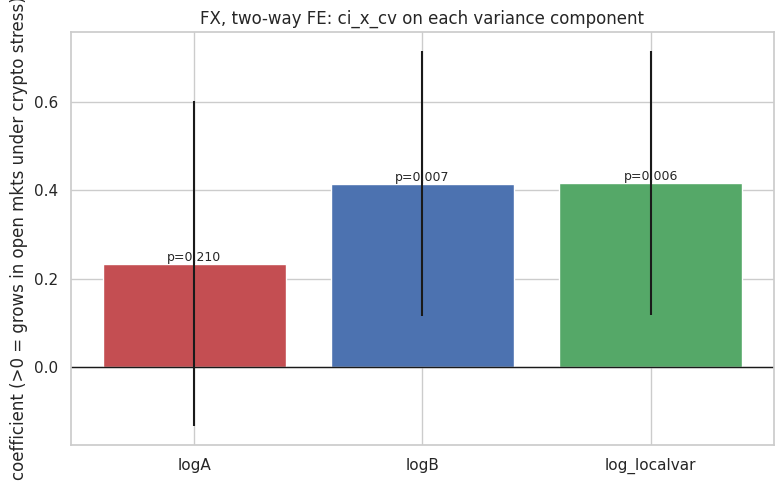

,coef,pval,nobs
measure,,,
logA,0.234274,0.210398,131312
logB,0.414967,0.006651,131312
log_localvar,0.415986,0.006269,131312


In [7]:
measures = ["logA", "logB", "log_localvar"]
m = decomp[(decomp.term == "ci_x_cv") & (decomp.channel == "fx") & (decomp.spec == "twfe")]
m = m.set_index("measure").reindex(measures)
err = 1.96 * m.se if "se" in m else None

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(measures, m.coef, yerr=err, color=["C3", "C0", "C2"])
for i, (_, r) in enumerate(m.iterrows()):
    ax.text(i, r.coef, f"p={r.pval:.3f}", ha="center", va="bottom", fontsize=9)
ax.axhline(0, c="k", lw=1)
ax.set(title="FX, two-way FE: ci_x_cv on each variance component",
       ylabel="coefficient (>0 = grows in open mkts under crypto stress)")
plt.tight_layout(); plt.show()
m[["coef", "pval", "nobs"]]

## 7. Crisis flags, the cases we keep + flag

Idiosyncratic hyperinflation/devaluation country-years, flagged by an objective rule (CPI ≥ 25% or FX depreciation ≥ 30%). We *keep* them in the sample but flag them for a leave-them-out robustness check. (Run `make crisis` if this is empty.)

In [8]:
if crisis is None:
    print("crisis_flags.parquet not found, run `make crisis` (needs network).")
else:
    flagged = crisis[crisis.crisis == 1].sort_values(["country_id", "year"])
    print(f"{len(flagged)} flagged country-years across {flagged.country_id.nunique()} countries")
    display(flagged[["country_id", "year", "inflation_pct", "fx_depreciation", "reason"]])

28 flagged country-years across 11 countries


,country_id,year,inflation_pct,fx_depreciation,reason
0,ARG,2019,53.548304,NaN,inflation
1,ARG,2020,42.015095,0.405011,inflation+fx
2,ARG,2021,48.409379,0.220375,inflation
3,ARG,2022,72.430758,0.722291,inflation+fx
4,ARG,2023,133.488936,3.568750,inflation+fx
6,ARG,2025,NaN,0.413232,fx
143,EGY,2022,13.895661,0.577991,fx
144,EGY,2023,33.884776,0.248658,inflation
145,EGY,2024,NaN,0.644743,fx
185,GHA,2022,31.255895,0.492537,inflation+fx


## Takeaway

What you can actually defend:

1. the sample is chosen by a transparent, pre-registered rule (no cherry-picking),
2. the spillover **share** is the thing we explain,
3. in FX, crypto's *share* of variance rises *less* with crypto stress in open markets, the **reverse of H2** (a share result, never "openness dampens crypto"),
4. that's **not** generic global risk-off (crypto survives openness×VIX / ×DXY; opposite-sign VIX in equity),
5. but it's **not separable from financial development**, `development × crypto` kills `openness × crypto` (p→~0.9), so read it as *financial-market maturity*, not capital controls specifically,
6. the variance *mechanism* is **unresolved** (absolute crypto level is flat; the "bigger pie" fails an independent test),
7. hyperinflation cases are handled honestly (kept + flagged).

Next: the results are reported in the thesis, and in the generated tables under `thesis/tables/`.